# The Augmented Synthetic Control Method
### Ben-Michael, Feller and Rothstein

This notebook reproduces the ATT, L2 imbalance and average estimated
bias of the Kansas example from the 2021 paper "The Augmented Synthetic
Control Method" by Eli Ben-Michael, Avi Feller and Jesse Rothstein, *Journal
of the American Statistical Association* 116(536):1789-1803, of the published outputs of the R
[`augsynth`](https://github.com/ebenmichael/augsynth) package (see the package
vignette `singlesynth-vignette`). The study data is contained in the file
`../../data/kansas.csv` (converted from the R `augsynth` package
`data/kansas.rda`).

In [1]:
import pandas as pd
import numpy as np

from pysyncon import Dataprep, AugSynth

The study data is prepared using a `Dataprep` object that describes all
the details needed to define the synthetic control study. This works similarly
to the `dataprep` method in the `R` package `synth`.

The example in the R `augsynth` package has no covariates
(`lngdpcapita ~ treated`), so we set `predictors=[]` and use
`use_covariates=False`; the ridge parameter $\lambda$ is selected by
cross-validation (using the 1-standard-error rule). Note that
`time_optimize_ssr` must contain all of the pre-treatment time periods (all
quarters before the treatment time 2012.25).

(For an explanation of each of the `Dataprep` arguments, see the package
[documentation](https://sdfordham.github.io/pysyncon/dataprep.html#pysyncon.Dataprep)).

In [2]:
df = pd.read_csv("../../data/kansas.csv")

fips = sorted(df.fips.unique())
pre = sorted(df.loc[df.year_qtr < 2012.25, "year_qtr"].unique())

dataprep = Dataprep(
    foo=df,
    predictors=[],
    predictors_op="mean",
    time_predictors_prior=pre,  # unused; no covariates in this fit
    dependent="lngdpcapita",
    unit_variable="fips",
    time_variable="year_qtr",
    treatment_identifier=20,
    controls_identifier=[f for f in fips if f != 20],
    time_optimize_ssr=pre,
)

print(dataprep)

Dataprep
Treated unit: 20
Dependent variable: lngdpcapita
Control units: 1.0, 2.0, 4.0, 5.0, 6.0, 8.0, 9.0, 10.0, 12.0, 13.0, 15.0, 16.0, 17.0, 18.0, 19.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 53.0, 54.0, 55.0, 56.0
Time range in data: 1990.0 - 2016.0
Time range for loss minimization: [1990.0, 1990.25, 1990.5, 1990.75, 1991.0, 1991.25, 1991.5, 1991.75, 1992.0, 1992.25, 1992.5, 1992.75, 1993.0, 1993.25, 1993.5, 1993.75, 1994.0, 1994.25, 1994.5, 1994.75, 1995.0, 1995.25, 1995.5, 1995.75, 1996.0, 1996.25, 1996.5, 1996.75, 1997.0, 1997.25, 1997.5, 1997.75, 1998.0, 1998.25, 1998.5, 1998.75, 1999.0, 1999.25, 1999.5, 1999.75, 2000.0, 2000.25, 2000.5, 2000.75, 2001.0, 2001.25, 2001.5, 2001.75, 2002.0, 2002.25, 2002.5, 2002.75, 2003.0, 2003.25, 2003.5, 2003.75, 2004.0, 2004.25, 2004.5, 2004.75, 2005.0, 2005.25, 2005.5, 2005.75, 2006.0, 2006.25, 2006.5, 2

We supply the `Dataprep` object to an `AugSynth` object. The augmented
weights are $w = w_{\text{scm}} + w_{\text{aug}}$ where $w_{\text{scm}}$ are
the standard synthetic control weights and $w_{\text{aug}}$ is an augmentation
obtained by ridge regression of the imbalance of the synthetic control fit on
the pre-treatment outcomes; the ridge parameter $\lambda$ controls the degree
of extrapolation. The weights may be negative and larger than 1.

In [3]:
augsynth = AugSynth()
augsynth.fit(dataprep, use_covariates=False)

The following table compares the results with those published in the R
`augsynth` vignette for this example (`progfunc="Ridge"`, `scm=T`, `lambda`
chosen by cross-validation):

In [4]:
att = augsynth.att(time_period=augsynth.post_periods)["att"]
l2 = augsynth.l2_imbalance
pct_improv = 100 * (1 - augsynth.scaled_l2_imbalance)
n_donors = (np.abs(augsynth.W) > 1 / (1000 * len(augsynth.W))).sum()

pd.DataFrame(
    {
        "pysyncon": [att, l2, pct_improv, augsynth.avg_bias, n_donors],
        "R augsynth vignette": [-0.0401, 0.062, 84.7, 0.011, 49],
    },
    index=[
        "Average ATT estimate",
        "L2 imbalance",
        "% improvement over uniform weights",
        "Avg Estimated Bias",
        "Donor units used",
    ],
).round(4)

,pysyncon,R augsynth vignette
Average ATT estimate,-0.0401,-0.0401
L2 imbalance,0.0615,0.0620
% improvement over uniform weights,84.7008,84.7000
Avg Estimated Bias,0.0106,0.0110
Donor units used,49.0000,49.0000


The donor units with the largest weights (only weights above 0.01 in
absolute value are shown) are:

In [5]:
augsynth.weights(round=4, threshold=0.01).sort_values(ascending=False)

45.0    0.3162
53.0    0.2368
48.0    0.1778
38.0    0.1231
54.0    0.0850
2.0     0.0710
21.0    0.0671
40.0    0.0296
49.0    0.0182
34.0    0.0160
17.0    0.0151
Name: weights, dtype: float64

The `path_plot` method shows the path of the treated unit and the
synthetic control over time.

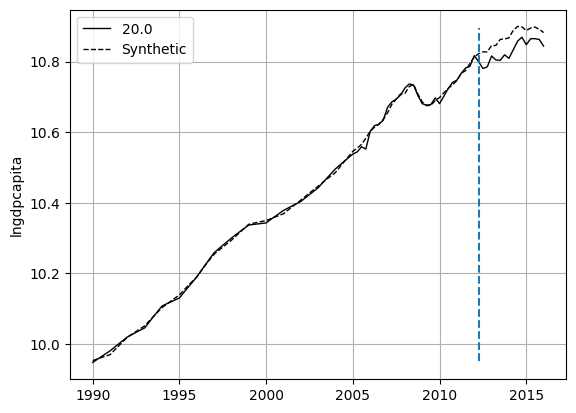

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='lngdpcapita'>)

In [6]:
augsynth.path_plot(
    time_period=sorted(df.year_qtr.unique()), treatment_time=2012.25
)

The `gaps_plot` method shows the gaps (the difference between the
treated unit and the synthetic control) over time.

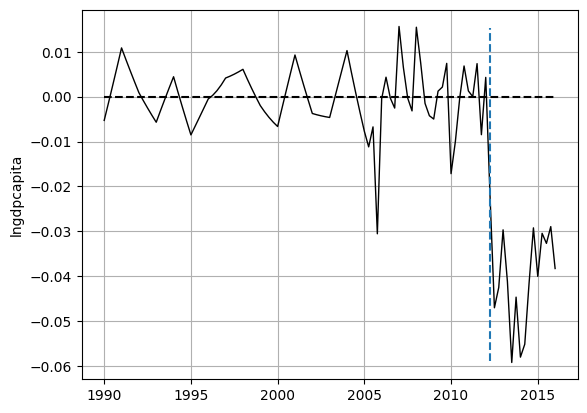

In [7]:
augsynth.gaps_plot(
    time_period=sorted(df.year_qtr.unique()), treatment_time=2012.25
)

Compute the average treatment effect on the treated unit (ATT) over the
post-treatment time period. This method returns a standard error also.

In [8]:
augsynth.att(time_period=augsynth.post_periods)

{'att': -0.040062844087144556, 'se': 0.0027464968535451375}

When `lambda_` is not supplied, it is obtained by cross-validation over a
grid of 21 log-spaced values. The `cv_result` attribute contains the
cross-validation results; `cv_result.plot()` plots the mean cross-validation
error against $\lambda$ with standard error bars.

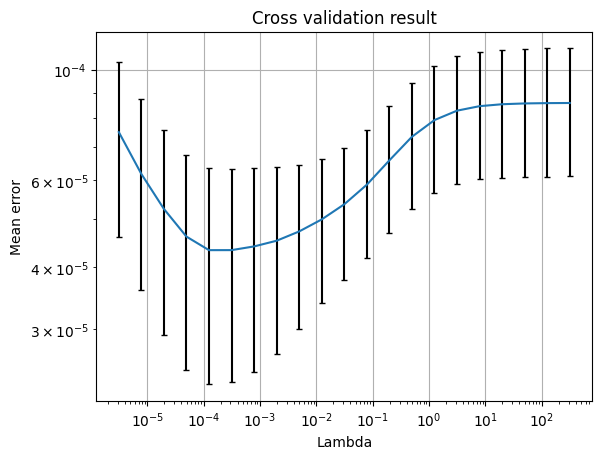

min-error lambda: 0.0001246712298749806
1-SE-selected lambda: 0.07866222813499749


In [9]:
augsynth.cv_result.plot()
print(
    "min-error lambda:",
    augsynth.cv_result.lambdas[augsynth.cv_result.errors_mean.argmin()],
)
print("1-SE-selected lambda:", augsynth.cv_result.best_lambda(min_1se=True))